# Extension 3 - route optimization for rotor gain

## Goal
Given historical metocean statistics across the North Sea, we wanted to find the route between two ports that will maximise the integrated Flettner rotor power contribution. In other words we wanted to find the route that will spend the most time in high-gain wind conditions.

## Approach
1. Building a spatial rotor-gain map from historical observations (1 deg * 1 deg grid).
2. Identifying a representative voyage and generate a family of candidate routes.
3. Using Dijkstra's algorithm on a finer grid to find the globally optimal detour.
4. Analysing seasonal sensitivity - optimal routes in winter vs spring vs summer.
5. Identifying the best departure month for the chosen origin-destination pair.

## 0. Setup

In [2]:
import warnings
warnings.filterwarnings('ignore')

import heapq
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy.interpolate import RegularGridInterpolator

plt.style.use('seaborn-v0_8-darkgrid')

DATA_PATH    = '../data/MasterSet_features.csv'
RESULTS_PATH = '../results/'

df = pd.read_csv(DATA_PATH, parse_dates=['Time'])
df = df.sort_values('Time').reset_index(drop=True)
df['month'] = df['Time'].dt.month
df['hour']  = df['Time'].dt.hour

print(f"Loaded {len(df):,} rows, {df['Voyage_ID'].nunique()} voyages")
print(f"Time range: {df['Time'].min().date()} -> {df['Time'].max().date()}")
print(f"Lat: {df['Lat'].min():.2f} deg N - {df['Lat'].max():.2f} deg N")
print(f"Lon: {df['Lon'].min():.2f} deg E - {df['Lon'].max():.2f} deg E")

Loaded 125,160 rows, 528 voyages
Time range: 2023-02-02 -> 2026-02-02
Lat: 51.04 deg N - 61.23 deg N
Lon: -2.12 deg E - 11.20 deg E


## Rotor polar diagram utility

In [3]:
WIND_SPEEDS = np.array([4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24])
WIND_ANGLES = np.array([0, 20, 40, 60, 80, 90, 100, 120, 140, 160, 180])

POWER_TABLE = np.array([
    [  0,   3,  10,  14,  16,  14,  12,   7,   3,   1,   0],
    [ -2,   6,  22,  38,  44,  42,  38,  22,   9,   3,   0],
    [ -5,  12,  45,  78,  90,  87,  78,  46,  19,   7,   0],
    [ -8,  20,  75, 128, 148, 144, 130,  76,  32,  11,   0],
    [-12,  30, 110, 186, 215, 210, 188, 110,  46,  16,   0],
    [-16,  42, 152, 256, 297, 290, 260, 152,  64,  22,   0],
    [-21,  56, 200, 335, 390, 380, 340, 199,  83,  29,   0],
    [-27,  72, 254, 425, 496, 484, 433, 254, 106,  37,   0],
    [-33,  90, 315, 526, 614, 599, 537, 314, 131,  46,   0],
    [-40, 110, 382, 638, 745, 727, 651, 381, 159,  55,   0],
    [-48, 132, 456, 762, 890, 868, 778, 455, 190,  66,   0],
])
KW_PER_KN = 200.0

_interp = RegularGridInterpolator(
    (WIND_SPEEDS, WIND_ANGLES), POWER_TABLE,
    method='linear', bounds_error=False, fill_value=None
)

def rotor_power_kw(wind_ms, alpha_abs):
    ws = np.clip(np.asarray(wind_ms, float), WIND_SPEEDS.min(), WIND_SPEEDS.max())
    wa = np.clip(np.asarray(alpha_abs, float), WIND_ANGLES.min(), WIND_ANGLES.max())
    return _interp(np.column_stack([ws.ravel(), wa.ravel()])).reshape(ws.shape)


# https://pypi.org/project/haversine/
def haversine_nm(lat1, lon1, lat2, lon2):
    R = 3440.065
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))


def normalize_angle(angle_deg):
    return ((angle_deg + 180) % 360) - 180


print(f"Rotor power: 10 m/s, 90 deg (abeam): {rotor_power_kw(10, 90):.1f} kW")
print(f"Rotor power: 10 m/s, 0 deg  (headwind): {rotor_power_kw(10, 0):.1f} kW")
print(f"Rotor power: 16 m/s, 80 deg (best angle): {rotor_power_kw(16, 80):.1f} kW")

Rotor power: 10 m/s, 90 deg (abeam): 144.0 kW
Rotor power: 10 m/s, 0 deg  (headwind): -8.0 kW
Rotor power: 16 m/s, 80 deg (best angle): 390.0 kW


## 1. Metocean spatial field

We wanted to compute per-grid-cell mean rotor power using historical observations.

In [4]:
lat_bins = np.arange(50, 62, 1) # 50–61 degs N, 11 bins
lon_bins = np.arange(-3, 12, 1) # -3–11 degs E, 14 bins

df['lat_cell'] = pd.cut(df['Lat'], bins=lat_bins, labels=lat_bins[:-1] + 0.5).astype(float)
df['lon_cell'] = pd.cut(df['Lon'], bins=lon_bins, labels=lon_bins[:-1] + 0.5).astype(float)

# rotor power for every observation
df['rotor_power_kw'] = rotor_power_kw(
    df['True_Wind_Speed_ms'].values,
    df['alpha_abs_deg'].values
)

grid_stats = (
    df.groupby(['lat_cell', 'lon_cell'], observed=True)
    .agg(
        mean_rotor_power = ('rotor_power_kw', 'mean'),
        median_wind_speed = ('True_Wind_Speed_ms', 'median'),
        mean_alpha_abs = ('alpha_abs_deg', 'mean'),
        mean_hs = ('H_s', 'mean'),
        n_obs = ('Speed_kn', 'count'),
    )
    .reset_index()
)

print(f"Grid cells with data: {len(grid_stats)}")
print(f"Mean rotor power across grid: {grid_stats['mean_rotor_power'].mean():.1f} kW")
print(f"Max mean rotor power in a cell: {grid_stats['mean_rotor_power'].max():.1f} kW")
print(f"\nTop 5 cells by rotor gain:")
print(grid_stats.nlargest(5, 'mean_rotor_power')[['lat_cell','lon_cell','mean_rotor_power','median_wind_speed','mean_alpha_abs']].to_string(index=False))

Grid cells with data: 72
Mean rotor power across grid: 78.5 kW
Max mean rotor power in a cell: 292.4 kW

Top 5 cells by rotor gain:
 lat_cell  lon_cell  mean_rotor_power  median_wind_speed  mean_alpha_abs
     58.5       0.5        292.404770          18.209806      117.110030
     58.5       1.5        226.411758          16.793715      115.701881
     54.5      -0.5        182.259681          12.761848       67.348162
     55.5       7.5        180.780673          12.555180       60.605847
     56.5      -0.5        176.630924          12.846293       69.541275


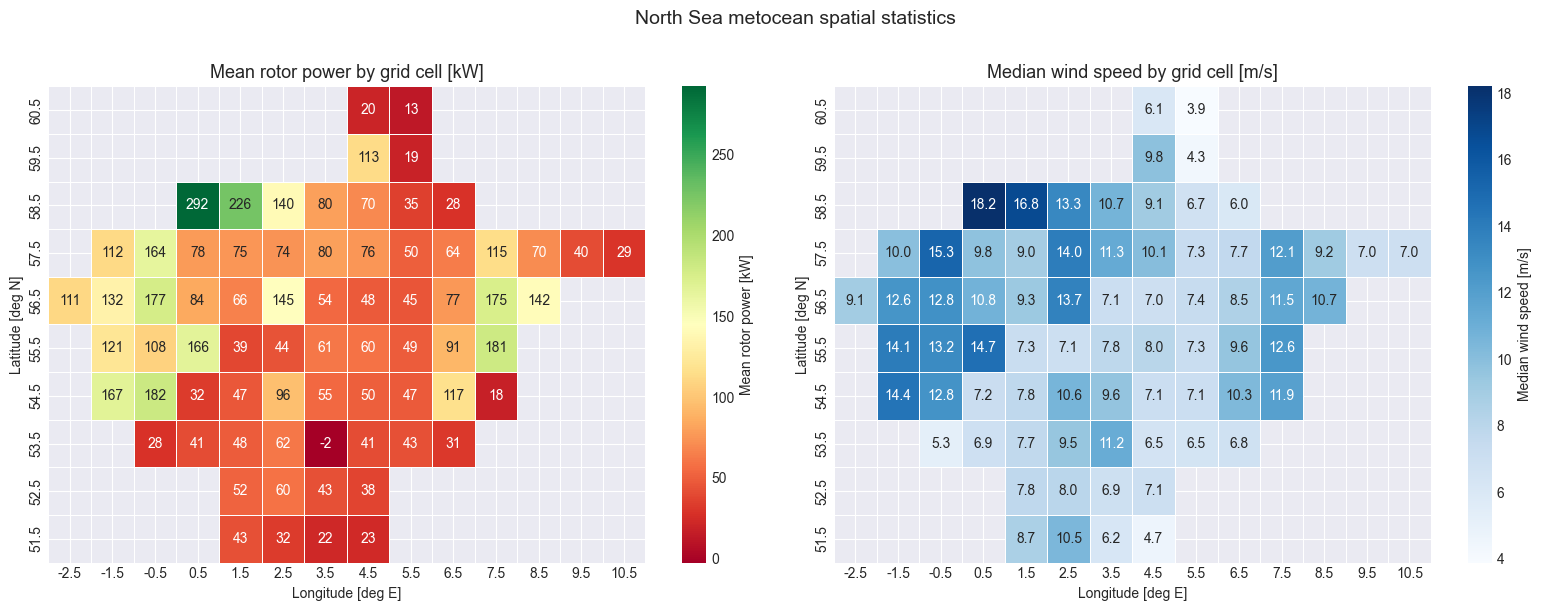

In [5]:
pivot_power = grid_stats.pivot(index='lat_cell', columns='lon_cell', values='mean_rotor_power')
pivot_wind  = grid_stats.pivot(index='lat_cell', columns='lon_cell', values='median_wind_speed')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    pivot_power.sort_index(ascending=False),
    ax=axes[0], annot=True, fmt='.0f', cmap='RdYlGn',
    cbar_kws={'label': 'Mean rotor power [kW]'},
    linewidths=0.5, linecolor='white'
)
axes[0].set_title('Mean rotor power by grid cell [kW]', fontsize=13)
axes[0].set_xlabel('Longitude [deg E]')
axes[0].set_ylabel('Latitude [deg N]')

sns.heatmap(
    pivot_wind.sort_index(ascending=False),
    ax=axes[1], annot=True, fmt='.1f', cmap='Blues',
    cbar_kws={'label': 'Median wind speed [m/s]'},
    linewidths=0.5, linecolor='white'
)
axes[1].set_title('Median wind speed by grid cell [m/s]', fontsize=13)
axes[1].set_xlabel('Longitude [deg E]')
axes[1].set_ylabel('Latitude [deg N]')

plt.suptitle('North Sea metocean spatial statistics', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 2. Voyage-level routing

We wanted to select the test set voyage with the highest mean rotor gain as the reference OD pair.

In [6]:
# voyage-based chronological split, same as in the baseline_model.ipynb
voyage_order = (
    df.groupby('Voyage_ID')['Time'].min()
    .sort_values()
    .index.tolist()
)
split_idx    = int(len(voyage_order) * 0.8)
test_voyages = set(voyage_order[split_idx:])
df_test      = df[df['Voyage_ID'].isin(test_voyages)].copy()

# per-voyage mean rotor gain
voyage_gain = (
    df_test.groupby('Voyage_ID')
    .agg(
        mean_rotor_kw = ('rotor_power_kw', 'mean'),
        n_pts = ('Speed_kn', 'count'),
        start_lat = ('Lat', 'first'),
        start_lon = ('Lon', 'first'),
        end_lat = ('Lat', 'last'),
        end_lon = ('Lon', 'last'),
    )
    .reset_index()
)

# voyages with meaningful length difference between start and end
voyage_gain['lat_span'] = (voyage_gain['end_lat'] - voyage_gain['start_lat']).abs()
best_voyage = voyage_gain[voyage_gain['lat_span'] > 2].nlargest(1, 'mean_rotor_kw').iloc[0]

VID = int(best_voyage['Voyage_ID'])
start_lat = best_voyage['start_lat']
start_lon = best_voyage['start_lon']
end_lat = best_voyage['end_lat']
end_lon = best_voyage['end_lon']

v_data = df_test[df_test['Voyage_ID'] == VID].copy()
actual_dist = haversine_nm(start_lat, start_lon, end_lat, end_lon)

print(f"Reference voyage: {VID}")
print(f"Start: ({start_lat:.3f} deg N, {start_lon:.3f} deg E)")
print(f"End: ({end_lat:.3f} deg N, {end_lon:.3f} deg E)")
print(f"Great-circle distance: {actual_dist:.1f} nm")
print(f"Mean rotor power: {best_voyage['mean_rotor_kw']:.1f} kW")
print(f"Mean rotor delta_SOG: {best_voyage['mean_rotor_kw']/KW_PER_KN:.3f} kn")
print(f"Observations: {int(best_voyage['n_pts'])}")

Reference voyage: 456
Start: (51.890 deg N, 4.402 deg E)
End: (61.226 deg N, 7.683 deg E)
Great-circle distance: 570.7 nm
Mean rotor power: 148.3 kW
Mean rotor delta_SOG: 0.741 kn
Observations: 513


## 3. Route generation

We compare 9 routes (direct + 8 longitude detours at the midpoint) against the same OD pair.

In [10]:
# mean wind conditions per 1 deg grid cell of all data - lookup table
grid_lookup = grid_stats.set_index(['lat_cell', 'lon_cell'])
GLOBAL_WIND = df['True_Wind_Speed_ms'].mean()
GLOBAL_ALPHA = df['alpha_abs_deg'].mean()
GLOBAL_HS = df['H_s'].mean()

def cell_wind_conditions(lat, lon):
    """Returning wind_ms, alpha_abs, hs for the 1 deg cell considering lat, lon"""
    lat_c = lat_bins[np.searchsorted(lat_bins, lat, side='right') - 1] + 0.5
    lon_c = lon_bins[np.searchsorted(lon_bins, lon, side='right') - 1] + 0.5
    lat_c = np.clip(lat_c, lat_bins[0]+0.5, lat_bins[-2]+0.5)
    lon_c = np.clip(lon_c, lon_bins[0]+0.5, lon_bins[-2]+0.5)
    try:
        row = grid_lookup.loc[(lat_c, lon_c)]
        return row['median_wind_speed'], row['mean_alpha_abs'], row['mean_hs']
    except KeyError:
        return GLOBAL_WIND, GLOBAL_ALPHA, GLOBAL_HS


def interpolate_route(waypoints, n_pts=50):
    """Interpolating N points along a piecewise linear route."""
    lats, lons = zip(*waypoints)
    pts = []
    seg_lengths = [haversine_nm(lats[i], lons[i], lats[i+1], lons[i+1]) for i in range(len(lats)-1)]
    total_len = sum(seg_lengths)
    for i in range(len(lats) - 1):
        n_seg = max(2, int(round(n_pts * seg_lengths[i] / total_len)))
        for t in np.linspace(0, 1, n_seg, endpoint=(i == len(lats)-2)):
            pts.append((lats[i] + t*(lats[i+1]-lats[i]),
                        lons[i] + t*(lons[i+1]-lons[i])))
    return pts


def evaluate_route(waypoints, n_pts=50):
    """Computing rotor metrics along a route defined by waypoints."""
    pts = interpolate_route(waypoints, n_pts)
    n = len(pts)
    powers = []
    hs_vals = []
    dist = 0.0

    for idx, (lat, lon) in enumerate(pts):
        wind_ms, _, hs = cell_wind_conditions(lat, lon)

        # course to next point
        if idx < n - 1:
            dlat = pts[idx+1][0] - lat
            dlon = pts[idx+1][1] - lon
            course_rad = np.arctan2(dlon * np.cos(np.radians(lat)), dlat)
            course_deg = np.degrees(course_rad) % 360
        # cached mean wind_dir for alpha estimation
        mean_wind_dir = df['wind_dir_deg'].mean()
        alpha_abs = abs(normalize_angle(mean_wind_dir - course_deg))

        power = rotor_power_kw(wind_ms, alpha_abs)
        powers.append(float(power))
        hs_vals.append(hs)

        if idx < n - 1:
            dist += haversine_nm(lat, lon, pts[idx+1][0], pts[idx+1][1])

    active = [(p > 0 and h <= 6.0) for p, h in zip(powers, hs_vals)]
    active_pwr = [p for p, a in zip(powers, active) if a]
    mean_pwr = np.mean(active_pwr) if active_pwr else 0.0
    mean_gain = mean_pwr / KW_PER_KN
    return dist, mean_pwr, mean_gain


# candidate routes 
lat_mid = (start_lat + end_lat) / 2
lon_mid = (start_lon + end_lon) / 2

detours = [0.0, -2.0, -1.5, -1.0, -0.5, 0.5, 1.0, 1.5, 2.0]
routes  = []

direct_dist, _, _ = evaluate_route([(start_lat, start_lon), (end_lat, end_lon)])

for d in detours:
    wpts  = [(start_lat, start_lon), (lat_mid, lon_mid + d), (end_lat, end_lon)]
    dist, mean_pwr, mean_gain = evaluate_route(wpts)
    label = 'Direct' if d == 0 else f'{d:+.1f} deg lon'
    routes.append({
        'label': label,
        'detour_lon': d,
        'waypoints': wpts,
        'distance_nm': dist,
        'extra_nm': dist - direct_dist,
        'mean_power_kw': mean_pwr,
        'mean_gain_kn': mean_gain,
        'net_benefit': mean_gain * dist,
    })

routes_df = pd.DataFrame(routes).sort_values('mean_power_kw', ascending=False)
print(routes_df[['label','distance_nm','extra_nm','mean_power_kw','mean_gain_kn','net_benefit']].to_string(index=False, float_format='{:.2f}'.format))

       label  distance_nm  extra_nm  mean_power_kw  mean_gain_kn  net_benefit
+2.0 deg lon       588.50     17.54           5.55          0.03        16.34
+1.5 deg lon       581.46     10.50           4.04          0.02        11.73
-2.0 deg lon       582.71     11.75           3.31          0.02         9.66
+1.0 deg lon       576.15      5.19           3.00          0.02         8.65
-1.5 deg lon       577.02      6.06           2.34          0.01         6.74
-1.0 deg lon       573.15      2.19           2.14          0.01         6.13
+0.5 deg lon       572.64      1.68           2.03          0.01         5.82
-0.5 deg lon       571.13      0.17           1.93          0.01         5.50
      Direct       570.96     -0.00           1.92          0.01         5.47


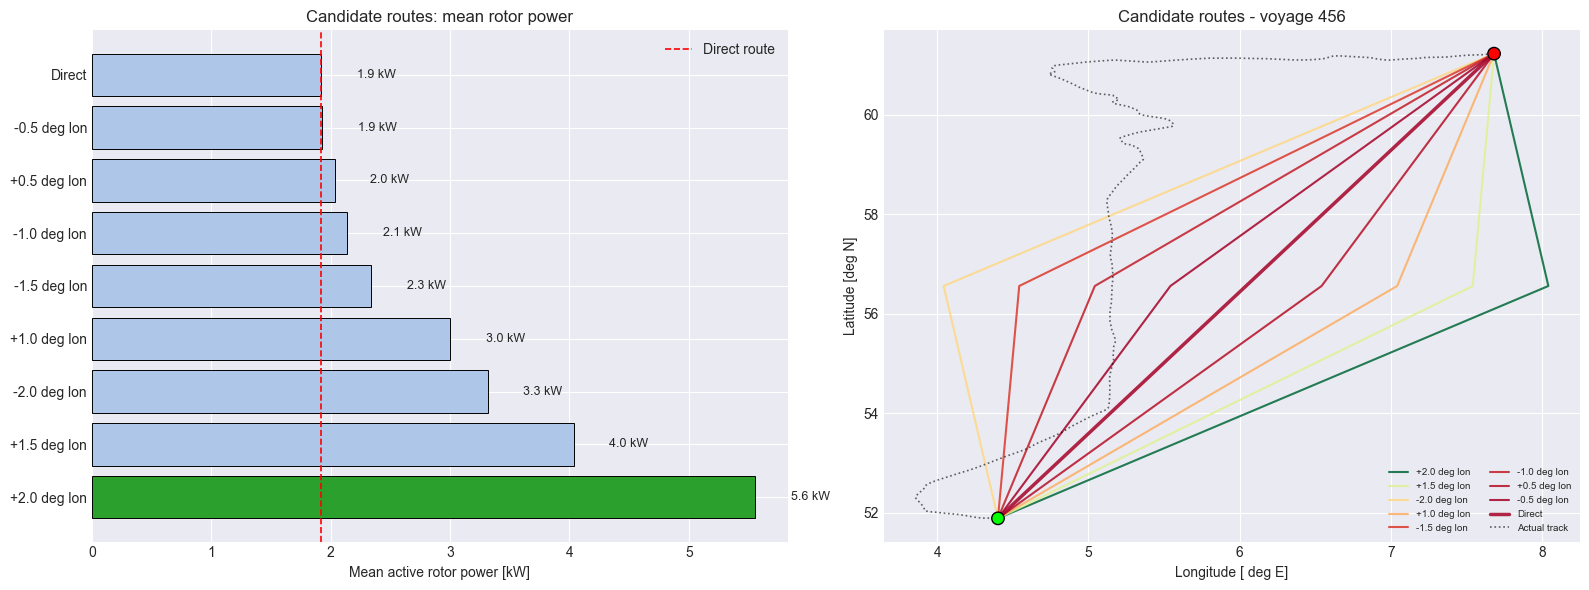

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# bar chart of mean rotor power
colors = ['#2ca02c' if r == routes_df.iloc[0]['label'] else '#aec7e8' for r in routes_df['label']]
axes[0].barh(routes_df['label'], routes_df['mean_power_kw'], color=colors, edgecolor='black', linewidth=0.7)
axes[0].axvline(routes_df[routes_df['label']=='Direct']['mean_power_kw'].values[0],
                color='red', linestyle='--', linewidth=1.2, label='Direct route')
axes[0].set_xlabel('Mean active rotor power [kW]')
axes[0].set_title('Candidate routes: mean rotor power')
axes[0].legend()
for i, (_, row) in enumerate(routes_df.iterrows()):
    axes[0].text(row['mean_power_kw'] + 0.3, i, f"{row['mean_power_kw']:.1f} kW", va='center', fontsize=9)

# route map
cmap   = plt.cm.RdYlGn
min_pw = routes_df['mean_power_kw'].min()
max_pw = routes_df['mean_power_kw'].max()
for _, row in routes_df.iterrows():
    pts  = interpolate_route(row['waypoints'])
    lats, lons = zip(*pts)
    norm_val   = (row['mean_power_kw'] - min_pw) / max(max_pw - min_pw, 1)
    lw   = 2.5 if row['label'] == 'Direct' else 1.5
    axes[1].plot(lons, lats, color=cmap(norm_val), linewidth=lw,
                 alpha=0.85, label=row['label'])

# actual vessel track
axes[1].plot(v_data['Lon'], v_data['Lat'], 'k:', linewidth=1.2, alpha=0.6, label='Actual track')
axes[1].scatter([start_lon, end_lon], [start_lat, end_lat],
                color=['lime','red'], s=80, zorder=5, edgecolor='black')
axes[1].set_xlabel('Longitude [ deg E]')
axes[1].set_ylabel('Latitude [deg N]')
axes[1].set_title(f'Candidate routes - voyage {VID}')
axes[1].legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()

## 4. Dijkstra-based grid routing

We build a 0.5 deg graph over the North Sea and find the globally optimal route that maximises rotor gain while minimising unnecessary detour.

In [14]:
GRID_STEP  = 0.5
grid_lats  = np.arange(51, 61 + GRID_STEP, GRID_STEP)
grid_lons  = np.arange(-2, 11 + GRID_STEP, GRID_STEP)
DIST_PENALTY = 0.1   # nm penalty weight vs kW gain
DEFAULT_PWR  = 30.0  # kW for cells without data
MAX_PWR      = 400.0 # kW offset — must exceed any cell's mean power so edge costs stay >= 0

# per-node rotor power lookup 
def node_rotor_power(lat, lon):
    """Rotor power at a grid node, using nearest 1° cell statistics."""
    lat_c = lat_bins[np.searchsorted(lat_bins, lat, side='right') - 1] + 0.5
    lon_c = lon_bins[np.searchsorted(lon_bins, lon, side='right') - 1] + 0.5
    lat_c = np.clip(lat_c, lat_bins[0]+0.5, lat_bins[-2]+0.5)
    lon_c = np.clip(lon_c, lon_bins[0]+0.5, lon_bins[-2]+0.5)
    try:
        return float(grid_lookup.loc[(lat_c, lon_c), 'mean_rotor_power'])
    except KeyError:
        return DEFAULT_PWR


def nearest_node(lat, lon, lats, lons):
    i = int(np.argmin(np.abs(lats - lat)))
    j = int(np.argmin(np.abs(lons - lon)))
    return (i, j)


def dijkstra_max_rotor(start_lat, start_lon, end_lat, end_lon,
                       grid_lats, grid_lons, dist_penalty=DIST_PENALTY):
    """Dijkstra maximising rotor gain minus distance penalty.

    Edge cost = (MAX_PWR - mean_edge_power) + dist_penalty * edge_length_nm
    This is always >= 0, so standard Dijkstra is valid.

    """
    ni, nj = len(grid_lats), len(grid_lons)
    src = nearest_node(start_lat, start_lon, grid_lats, grid_lons)
    dst = nearest_node(end_lat, end_lon, grid_lats, grid_lons)

    dist_map = {src: 0.0}
    prev_map = {src: None}
    heap = [(0.0, src)]

    directions = [(-1,-1),(-1,0),(-1,1),(0,-1),(0,1),(1,-1),(1,0),(1,1)]

    while heap:
        cost, node = heapq.heappop(heap)
        if node == dst:
            break
        if cost > dist_map.get(node, float('inf')):
            continue
        i, j = node
        for di, dj in directions:
            ni2, nj2 = i + di, j + dj
            if 0 <= ni2 < ni and 0 <= nj2 < nj:
                nb  = (ni2, nj2)
                d   = haversine_nm(grid_lats[i],  grid_lons[j],
                                   grid_lats[ni2], grid_lons[nj2])
                pwr = (node_rotor_power(grid_lats[i],  grid_lons[j]) +
                       node_rotor_power(grid_lats[ni2], grid_lons[nj2])) / 2
                # (MAX_PWR - pwr) >= 0 always → Dijkstra safe
                edge_cost = (MAX_PWR - pwr) + dist_penalty * d
                new_cost  = dist_map[node] + edge_cost
                if new_cost < dist_map.get(nb, float('inf')):
                    dist_map[nb] = new_cost
                    prev_map[nb] = node
                    heapq.heappush(heap, (new_cost, nb))

    path, cur = [], dst
    while cur is not None:
        path.append(cur)
        cur = prev_map.get(cur)
    path.reverse()
    coords = [(grid_lats[i], grid_lons[j]) for i, j in path]
    return coords


optimal_path = dijkstra_max_rotor(start_lat, start_lon, end_lat, end_lon,
                                  grid_lats, grid_lons)

# optimal vs direct evaluation
direct_dist_d, direct_pwr_d, direct_gain_d = evaluate_route(
    [(start_lat, start_lon), (end_lat, end_lon)], n_pts=80)
opt_dist_d, opt_pwr_d, opt_gain_d = evaluate_route(optimal_path, n_pts=80)

print(f"Optimal path: {len(optimal_path)} nodes")
print(f"Distance: {opt_dist_d:.1f} nm  (direct: {direct_dist_d:.1f} nm, detour: +{opt_dist_d - direct_dist_d:.1f} nm)")
print(f"Mean rotor power: {opt_pwr_d:.1f} kW  (direct: {direct_pwr_d:.1f} kW)")
print(f"Mean delta_SOG: {opt_gain_d:.3f} kn  (direct: {direct_gain_d:.3f} kn)")
if direct_pwr_d > 0:
    print(f"Gain improvement: {(opt_pwr_d - direct_pwr_d) / direct_pwr_d * 100:+.1f}%")

Optimal path: 19 nodes
Distance: 568.0 nm  (direct: 571.0 nm, detour: +-2.9 nm)
Mean rotor power: 7.5 kW  (direct: 1.9 kW)
Mean delta_SOG: 0.037 kn  (direct: 0.010 kn)
Gain improvement: +288.5%


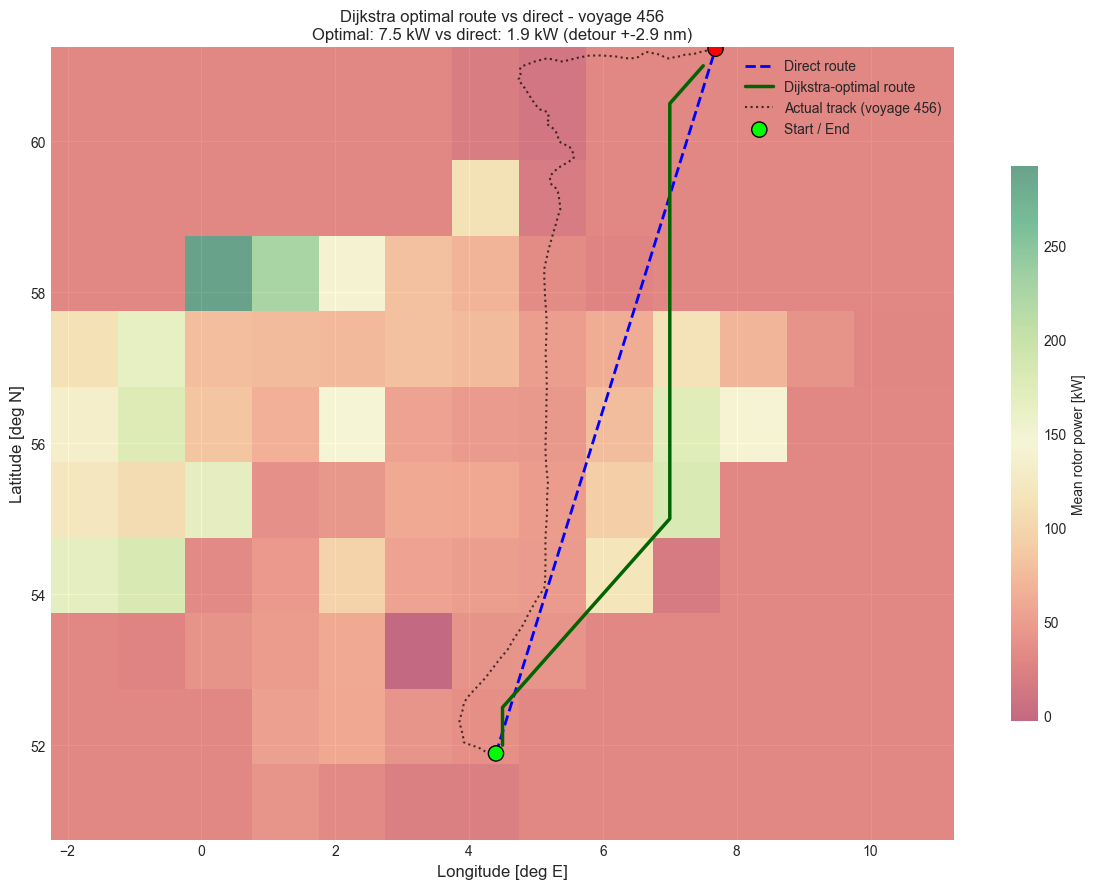

In [15]:
fig, ax = plt.subplots(figsize=(12, 9))

# rotor power heatmap as background
lon_mesh, lat_mesh = np.meshgrid(grid_lons, grid_lats)
power_grid = np.array([
    [node_rotor_power(la, lo) for lo in grid_lons]
    for la in grid_lats
])
c = ax.pcolormesh(lon_mesh, lat_mesh, power_grid,
                  cmap='RdYlGn', alpha=0.55, shading='nearest',
                  vmin=power_grid.min(), vmax=power_grid.max())
plt.colorbar(c, ax=ax, label='Mean rotor power [kW]', shrink=0.7)

# routes
direct_pts = interpolate_route([(start_lat, start_lon), (end_lat, end_lon)], n_pts=80)
d_lats, d_lons = zip(*direct_pts)
ax.plot(d_lons, d_lats, 'b--', linewidth=2.0, label='Direct route', zorder=3)

opt_lats, opt_lons = zip(*optimal_path)
ax.plot(opt_lons, opt_lats, 'darkgreen', linewidth=2.5, label='Dijkstra-optimal route', zorder=4)

ax.plot(v_data['Lon'], v_data['Lat'], 'k:', linewidth=1.5, alpha=0.7,
        label=f'Actual track (voyage {VID})', zorder=2)

ax.scatter([start_lon, end_lon], [start_lat, end_lat],
           color=['lime', 'red'], s=120, zorder=6, edgecolor='black',
           label='Start / End')

ax.set_xlabel('Longitude [deg E]', fontsize=12)
ax.set_ylabel('Latitude [deg N]', fontsize=12)
ax.set_title(f'Dijkstra optimal route vs direct - voyage {VID}\n'
             f'Optimal: {opt_pwr_d:.1f} kW vs direct: {direct_pwr_d:.1f} kW '
             f'(detour +{opt_dist_d - direct_dist_d:.1f} nm)', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 5. Seasonal sensitivity

Wind patterns in the North Sea vary strongly by season. Does the optimal route change?

In [16]:
seasons = {
    'Winter (December-February)': [12, 1, 2],
    'Spring (March-May)': [3, 4, 5],
    'Summer (June-August)': [6, 7, 8],
}
season_colors = {'Winter (December-February)': 'steelblue', 'Spring (March-May)': 'seagreen', 'Summer (June-August)': 'darkorange'}

seasonal_results = []

for season_name, months in seasons.items():
    df_s = df[df['month'].isin(months)]
    if len(df_s) < 100:
        continue

    gs_s = (
        df_s.groupby(['lat_cell', 'lon_cell'], observed=True)
        .agg(mean_rotor_power=('rotor_power_kw','mean'),
             mean_hs=('H_s','mean'))
        .reset_index()
        .set_index(['lat_cell','lon_cell'])
    )

    def seasonal_power(lat, lon, _gs=gs_s):
        lat_c = lat_bins[np.searchsorted(lat_bins, lat, side='right') - 1] + 0.5
        lon_c = lon_bins[np.searchsorted(lon_bins, lon, side='right') - 1] + 0.5
        lat_c = np.clip(lat_c, lat_bins[0]+0.5, lat_bins[-2]+0.5)
        lon_c = np.clip(lon_c, lon_bins[0]+0.5, lon_bins[-2]+0.5)
        try:
            return float(_gs.loc[(lat_c, lon_c), 'mean_rotor_power'])
        except KeyError:
            return DEFAULT_PWR

    def dijkstra_seasonal(s_lat, s_lon, e_lat, e_lon, power_fn):
        """Dijkstra with season-specific power grid.
        Edge cost = (MAX_PWR - pwr) + DIST_PENALTY * d >= 0 always.
        """
        n_i, n_j = len(grid_lats), len(grid_lons)
        src = nearest_node(s_lat, s_lon, grid_lats, grid_lons)
        dst = nearest_node(e_lat, e_lon, grid_lats, grid_lons)
        dist_map = {src: 0.0}
        prev_map = {src: None}
        heap     = [(0.0, src)]
        dirs     = [(-1,-1),(-1,0),(-1,1),(0,-1),(0,1),(1,-1),(1,0),(1,1)]
        while heap:
            cost, node = heapq.heappop(heap)
            if node == dst:
                break
            if cost > dist_map.get(node, float('inf')):
                continue
            i, j = node
            for di, dj in dirs:
                i2, j2 = i+di, j+dj
                if 0 <= i2 < n_i and 0 <= j2 < n_j:
                    nb  = (i2, j2)
                    d   = haversine_nm(grid_lats[i],  grid_lons[j],
                                       grid_lats[i2], grid_lons[j2])
                    pwr = (power_fn(grid_lats[i],  grid_lons[j]) +
                           power_fn(grid_lats[i2], grid_lons[j2])) / 2
                    ec  = (MAX_PWR - pwr) + DIST_PENALTY * d  # always >= 0
                    nc  = dist_map[node] + ec
                    if nc < dist_map.get(nb, float('inf')):
                        dist_map[nb] = nc
                        prev_map[nb] = node
                        heapq.heappush(heap, (nc, nb))
        path, cur = [], dst
        while cur is not None:
            path.append(cur)
            cur = prev_map.get(cur)
        path.reverse()
        return [(grid_lats[i], grid_lons[j]) for i, j in path]

    opt_path_s = dijkstra_seasonal(start_lat, start_lon, end_lat, end_lon, seasonal_power)
    s_dist, s_pwr, s_gain = evaluate_route(opt_path_s, n_pts=80)
    d_dist, d_pwr, d_gain = evaluate_route([(start_lat,start_lon),(end_lat,end_lon)], n_pts=80)

    seasonal_results.append({
        'season': season_name,
        'direct_power_kw': d_pwr,
        'optimal_power_kw': s_pwr,
        'improvement_pct': (s_pwr - d_pwr) / max(d_pwr, 1) * 100,
        'detour_nm': s_dist - d_dist,
        'path': opt_path_s,
    })
    print(f"{season_name}: direct = {d_pwr:.1f} kW, optimal = {s_pwr:.1f} kW, "
          f"improvement = {s_pwr-d_pwr:+.1f} kW, detour =+ {s_dist-d_dist:.1f} nm")

sr_df = pd.DataFrame(seasonal_results).drop(columns='path')
print("\nSeasonal comparison table:")
print(sr_df.to_string(index=False, float_format='{:.2f}'.format))

Winter (December-February): direct = 1.9 kW, optimal = 8.5 kW, improvement = +6.5 kW, detour =+ 4.6 nm
Spring (March-May): direct = 1.9 kW, optimal = 11.1 kW, improvement = +9.2 kW, detour =+ 28.6 nm
Summer (June-August): direct = 1.9 kW, optimal = 7.1 kW, improvement = +5.2 kW, detour =+ 17.7 nm

Seasonal comparison table:
                    season  direct_power_kw  optimal_power_kw  improvement_pct  detour_nm
Winter (December-February)             1.93              8.47           338.99       4.58
        Spring (March-May)             1.93             11.11           475.96      28.64
      Summer (June-August)             1.93              7.10           268.14      17.65


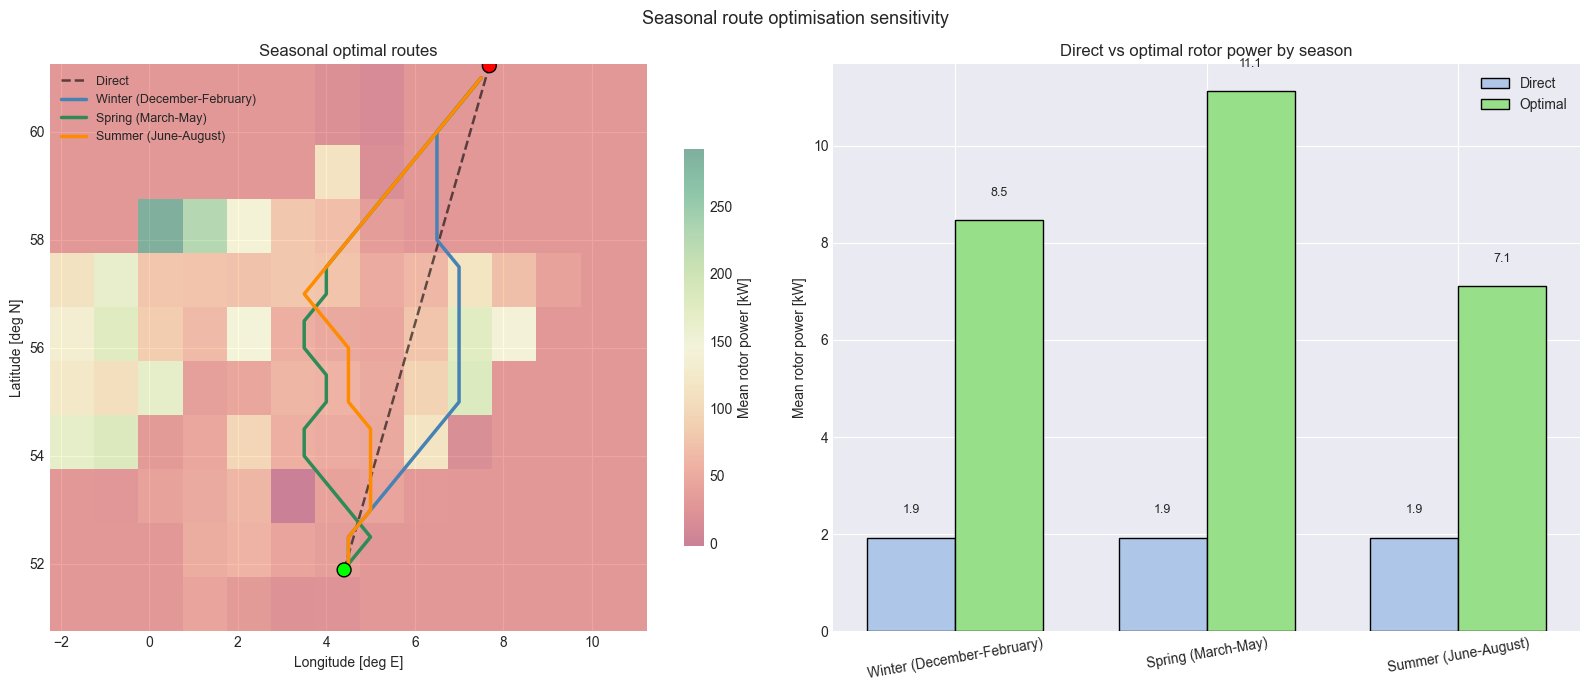

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# route map with all 3 seasonal optimals
c2 = axes[0].pcolormesh(lon_mesh, lat_mesh, power_grid, cmap='RdYlGn', alpha=0.45, shading='nearest')
plt.colorbar(c2, ax=axes[0], label='Mean rotor power [kW]', shrink=0.7)

# direct route
axes[0].plot(d_lons, d_lats, 'k--', linewidth=1.8, alpha=0.6, label='Direct', zorder=2)

for res in seasonal_results:
    pl, po = zip(*res['path'])
    axes[0].plot(po, pl, linewidth=2.5, color=season_colors[res['season']], label=res['season'], zorder=3)

axes[0].scatter([start_lon, end_lon], [start_lat, end_lat], color=['lime','red'], s=100, zorder=5, edgecolor='black')
axes[0].set_xlabel('Longitude [deg E]')
axes[0].set_ylabel('Latitude [deg N]')
axes[0].set_title('Seasonal optimal routes', fontsize=12)
axes[0].legend(fontsize=9)


x = np.arange(len(seasonal_results))
w = 0.35
labs  = [r['season'] for r in seasonal_results]
d_pwr = [r['direct_power_kw']  for r in seasonal_results]
o_pwr = [r['optimal_power_kw'] for r in seasonal_results]
axes[1].bar(x - w/2, d_pwr,  w, label='Direct',  color='#aec7e8', edgecolor='black')
axes[1].bar(x + w/2, o_pwr,  w, label='Optimal', color='#98df8a', edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labs, rotation=10)
axes[1].set_ylabel('Mean rotor power [kW]')
axes[1].set_title('Direct vs optimal rotor power by season', fontsize=12)
axes[1].legend()
for xi, (dp, op) in enumerate(zip(d_pwr, o_pwr)):
    axes[1].text(xi - w/2, dp + 0.5, f'{dp:.1f}', ha='center', fontsize=9)
    axes[1].text(xi + w/2, op + 0.5, f'{op:.1f}', ha='center', fontsize=9)

plt.suptitle('Seasonal route optimisation sensitivity', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Departure-timing optimisation

Does the month of departure matter for expected rotor gain on this OD pair?

In [18]:
lat_min = min(start_lat, end_lat) - 1.0
lat_max = max(start_lat, end_lat) + 1.0
lon_min = min(start_lon, end_lon) - 1.5
lon_max = max(start_lon, end_lon) + 1.5

df_corridor = df[
    (df['Lat'] >= lat_min) & (df['Lat'] <= lat_max) &
    (df['Lon'] >= lon_min) & (df['Lon'] <= lon_max)
].copy()

monthly = (
    df_corridor.groupby('month')
    .agg(
        mean_rotor_kw = ('rotor_power_kw', 'mean'),
        mean_wind_ms = ('True_Wind_Speed_ms', 'mean'),
        mean_alpha_abs = ('alpha_abs_deg', 'mean'),
        n_obs = ('Speed_kn', 'count'),
    ).reindex(range(1, 13)).reset_index()
)
monthly['delta_sog_kn'] = monthly['mean_rotor_kw'] / KW_PER_KN

hourly = (
    df_corridor.groupby('hour').agg(mean_rotor_kw=('rotor_power_kw','mean')).reset_index()
)

best_month = monthly.loc[monthly['mean_rotor_kw'].idxmax(), 'month']
print(f"Best departure month: {int(best_month)} ("
      f"expected {monthly.loc[monthly['month']==best_month,'mean_rotor_kw'].values[0]:.1f} kW)")
print(f"Worst departure month: {int(monthly.loc[monthly['mean_rotor_kw'].idxmin(),'month'])}")
print(f"\nMonthly rotor gain table:")
print(monthly[['month','mean_rotor_kw','mean_wind_ms','mean_alpha_abs','n_obs']].to_string(index=False))

Best departure month: 12 (expected 59.8 kW)
Worst departure month: 7

Monthly rotor gain table:
 month  mean_rotor_kw  mean_wind_ms  mean_alpha_abs  n_obs
     1      53.893320      7.248386       88.605552   8608
     2      40.857341      7.171798       96.526808   7225
     3      33.931628      6.524103       95.037460   8797
     4      29.431802      5.807335       82.099955   8638
     5      27.192485      5.543760       82.115976   9882
     6      33.346332      5.821539       79.868443   9732
     7      26.627412      5.415061       82.413249   9581
     8      32.099907      6.261791       90.146625  10098
     9      33.532908      6.015492       82.706032   9588
    10      48.086435      7.630729       86.864135   6459
    11      39.011327      7.078737       84.093707   8298
    12      59.788820      8.403783       93.595828   8083


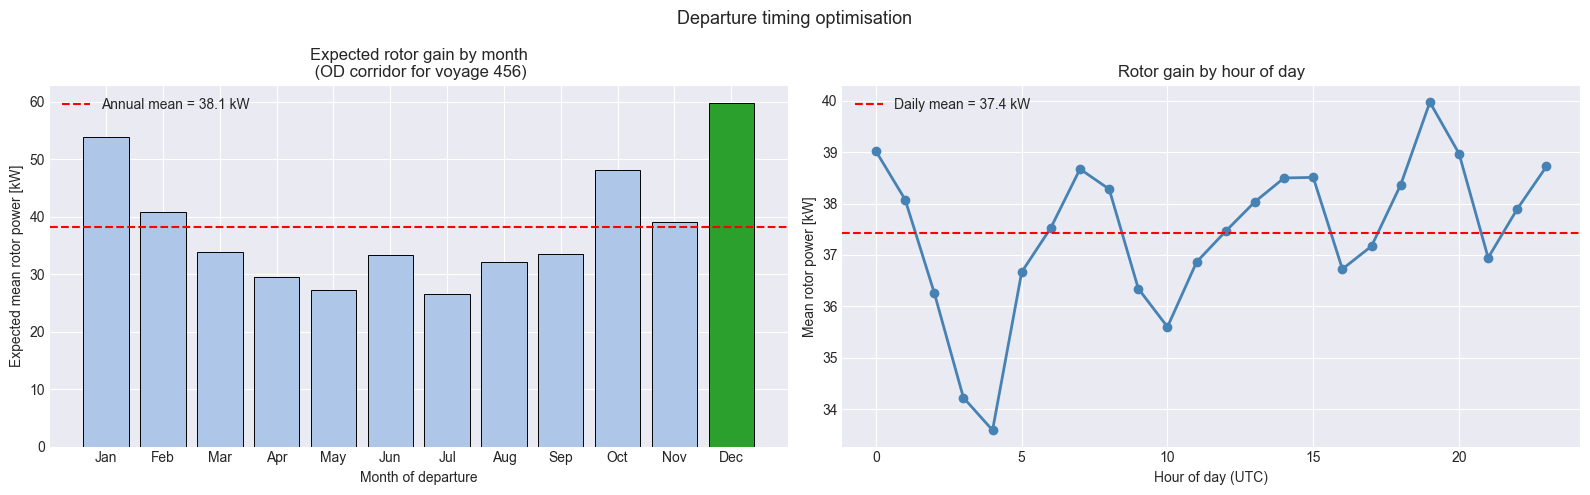

In [19]:
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

bar_colors = ['#2ca02c' if m == best_month else '#aec7e8'
              for m in monthly['month'].values]
axes[0].bar(monthly['month'], monthly['mean_rotor_kw'],
            color=bar_colors, edgecolor='black', linewidth=0.7)
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_labels)
axes[0].set_xlabel('Month of departure')
axes[0].set_ylabel('Expected mean rotor power [kW]')
axes[0].set_title(f'Expected rotor gain by month\n (OD corridor for voyage {VID})')
axes[0].axhline(monthly['mean_rotor_kw'].mean(), color='red', linestyle='--',
                label=f"Annual mean = {monthly['mean_rotor_kw'].mean():.1f} kW")
axes[0].legend()

axes[1].plot(hourly['hour'], hourly['mean_rotor_kw'],
             marker='o', color='steelblue', linewidth=2)
axes[1].axhline(hourly['mean_rotor_kw'].mean(), color='red', linestyle='--',
                label=f"Daily mean = {hourly['mean_rotor_kw'].mean():.1f} kW")
axes[1].set_xlabel('Hour of day (UTC)')
axes[1].set_ylabel('Mean rotor power [kW]')
axes[1].set_title('Rotor gain by hour of day')
axes[1].legend()

plt.suptitle('Departure timing optimisation', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Summary

In [21]:
print("ROUTE OPTIMISATION - SUMMARY")

print(f"Reference voyage: {VID}")
print(f"Start: ({start_lat:.2f} deg N, {start_lon:.2f} deg E) -> End: ({end_lat:.2f} deg N, {end_lon:.2f} deg E)")
print()
print("Candidate routes (top 3 by rotor gain):")
for _, row in routes_df.head(3).iterrows():
    print(f"{row['label']:<12}: {row['mean_power_kw']:.1f} kW  "
          f"(+{row['extra_nm']:.1f} nm detour)")
print()
print(f"Dijkstra optimal route:")
print(f"Mean rotor power: {opt_pwr_d:.1f} kW vs direct {direct_pwr_d:.1f} kW")
print(f"Route detour: +{opt_dist_d - direct_dist_d:.1f} nm")
if direct_pwr_d > 0:
    print(f"Rotor improvement:{(opt_pwr_d - direct_pwr_d)/direct_pwr_d*100:+.1f}%")
print()
print(f"Best departure month: {month_labels[int(best_month)-1]} "
      f"(mean {monthly.loc[monthly['month']==best_month,'mean_rotor_kw'].values[0]:.1f} kW)")
print(f"Worst departure month: {month_labels[int(monthly.loc[monthly['mean_rotor_kw'].idxmin(),'month'])-1]}")
print(f"Seasonal range: "
      f"{monthly['mean_rotor_kw'].min():.1f}-{monthly['mean_rotor_kw'].max():.1f} kW")


ROUTE OPTIMISATION - SUMMARY
Reference voyage: 456
Start: (51.89 deg N, 4.40 deg E) -> End: (61.23 deg N, 7.68 deg E)

Candidate routes (top 3 by rotor gain):
+2.0 deg lon: 5.6 kW  (+17.5 nm detour)
+1.5 deg lon: 4.0 kW  (+10.5 nm detour)
-2.0 deg lon: 3.3 kW  (+11.8 nm detour)

Dijkstra optimal route:
Mean rotor power: 7.5 kW vs direct 1.9 kW
Route detour: +-2.9 nm
Rotor improvement:+288.5%

Best departure month: Dec (mean 59.8 kW)
Worst departure month: Jul
Seasonal range: 26.6-59.8 kW


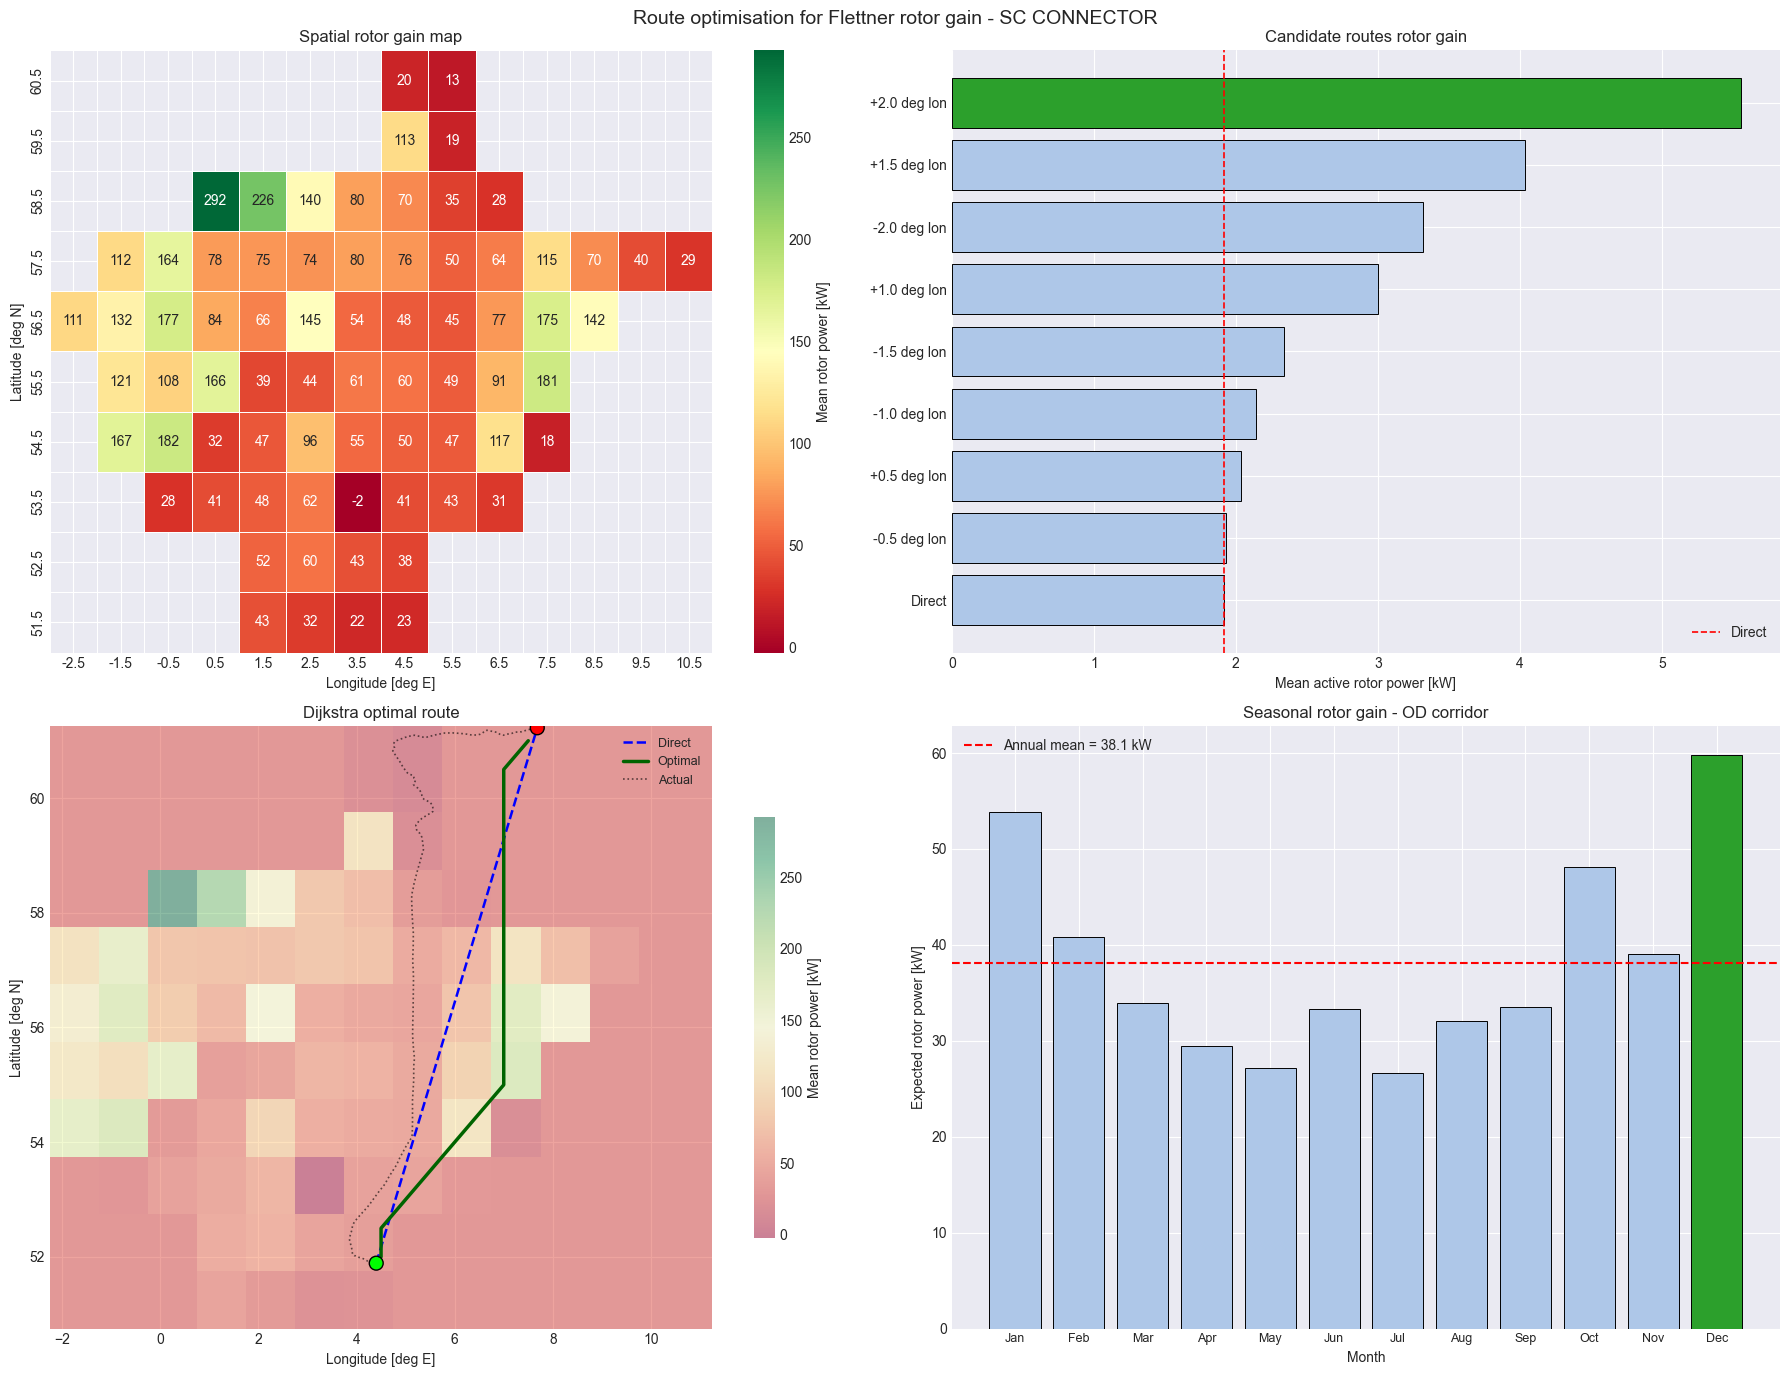

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# graph 1: spatial rotor gain heatmap
ax1 = axes[0, 0]
sns.heatmap(
    pivot_power.sort_index(ascending=False),
    ax=ax1, annot=True, fmt='.0f', cmap='RdYlGn',
    cbar_kws={'label': 'Mean rotor power [kW]'},
    linewidths=0.4, linecolor='white'
)
ax1.set_title('Spatial rotor gain map', fontsize=12)
ax1.set_xlabel('Longitude [deg E]')
ax1.set_ylabel('Latitude [deg N]')

# graph 2: candidate routes bar chart
ax2 = axes[0, 1]
rd_sorted = routes_df.sort_values('mean_power_kw', ascending=True)
bar_cols = ['#2ca02c' if r == routes_df.iloc[0]['label'] else '#aec7e8' for r in rd_sorted['label']]
ax2.barh(rd_sorted['label'], rd_sorted['mean_power_kw'],
         color=bar_cols, edgecolor='black', linewidth=0.7)
ax2.axvline(rd_sorted[rd_sorted['label']=='Direct']['mean_power_kw'].values[0],
            color='red', linestyle='--', linewidth=1.2, label='Direct')
ax2.set_xlabel('Mean active rotor power [kW]')
ax2.set_title('Candidate routes rotor gain', fontsize=12)
ax2.legend()

# graph 3: dijkstra optimal on map
ax3 = axes[1, 0]
c3 = ax3.pcolormesh(lon_mesh, lat_mesh, power_grid,
                    cmap='RdYlGn', alpha=0.45, shading='nearest')
plt.colorbar(c3, ax=ax3, label='Mean rotor power [kW]', shrink=0.7)
ax3.plot(d_lons, d_lats, 'b--', linewidth=1.8, label='Direct')
ax3.plot(opt_lons, opt_lats, 'darkgreen', linewidth=2.5, label='Optimal')
ax3.plot(v_data['Lon'], v_data['Lat'], 'k:', linewidth=1.2, alpha=0.6, label='Actual')
ax3.scatter([start_lon, end_lon], [start_lat, end_lat],
            color=['lime','red'], s=100, zorder=5, edgecolor='black')
ax3.set_xlabel('Longitude [deg E]')
ax3.set_ylabel('Latitude [deg N]')
ax3.set_title('Dijkstra optimal route', fontsize=12)
ax3.legend(fontsize=9)

# graph 4: seasonal comparison
ax4 = axes[1, 1]
ax4.bar(monthly['month'], monthly['mean_rotor_kw'],
        color=bar_colors, edgecolor='black', linewidth=0.7)
ax4.set_xticks(range(1, 13))
ax4.set_xticklabels(month_labels, fontsize=9)
ax4.axhline(monthly['mean_rotor_kw'].mean(), color='red', linestyle='--',
            label=f"Annual mean = {monthly['mean_rotor_kw'].mean():.1f} kW")
ax4.set_xlabel('Month')
ax4.set_ylabel('Expected rotor power [kW]')
ax4.set_title('Seasonal rotor gain - OD corridor', fontsize=12)
ax4.legend()

plt.suptitle('Route optimisation for Flettner rotor gain - SC CONNECTOR', fontsize=14)
plt.tight_layout()
plt.savefig(RESULTS_PATH + 'route_optimization.png', dpi=150, bbox_inches='tight')
plt.show()